In [1]:
import pathlib

import numpy as np
import pandas as pd

In [2]:
data_dir = pathlib.Path() / "../data/raw/biolog"

In [3]:
pairwise_df = pd.read_csv(data_dir / "pairwise_scores_rast.csv")

In [4]:
pairwise_df

,genome1,source1,genome2,source2,l1_norm,ji,corr
0,GCF_001421845.1,Leaf,GCF_001425385.1,Leaf,0.000000,1.000000,1.000000
1,GCF_001421315.1,Leaf,GCF_001423725.1,Leaf,0.000000,1.000000,1.000000
2,Novosphingobium_sp._GV076_2757320421.fna,PMI,Novosphingobium_sp._GV027_2738541275.fna,PMI,0.000000,1.000000,1.000000
3,GCF_001421605.1,Leaf,GCF_001421155.1,Leaf,0.000000,1.000000,1.000000
4,Paraburkholderia_sp._GV060_2738543008.fna,PMI,Paraburkholderia_sp._GV052_2738541306.fna,PMI,0.000000,1.000000,1.000000
...,...,...,...,...,...,...,...
634496,g83333.108,CH,Actinobacteria_bacterium_OK006_2639763183.fna,PMI,0.201609,0.150472,0.150624
634497,g83333.108,CH,Bacillus_sp._OK061_2615840539.fna,PMI,0.201692,0.153967,0.155155
634498,g562.13577,CH,Streptomyces_sp._OV198_2718217699.fna,PMI,0.202065,0.154460,0.156386
634499,g562.8507,CH,Actinobacteria_bacterium_OK006_2639763183.fna,PMI,0.202729,0.151094,0.151262


## Intra and Inter-Source similarity analysis

In [5]:
pairwise_df.drop(["genome1", "genome2"], axis=1).groupby(by=["source1", "source2"]).mean()

l1_norm        ji      corr
source1 source2                              
CH      CH       0.094490  0.322760  0.437574
        Leaf     0.099970  0.093626  0.158814
        PMI      0.104974  0.291154  0.396452
Leaf    Leaf     0.020726  0.477490  0.631787
PMI     Leaf     0.106148  0.095393  0.165184
        PMI      0.099461  0.340634  0.446828

In [6]:
# filter pairwise_df to only include pairs with a l1_norm of < 0.01?
filtered_pairwise_df = pairwise_df[pairwise_df["l1_norm"] < 0.01]
filtered_pairwise_df

,genome1,source1,genome2,source2,l1_norm,ji,corr
0,GCF_001421845.1,Leaf,GCF_001425385.1,Leaf,0.000000,1.000000,1.000000
1,GCF_001421315.1,Leaf,GCF_001423725.1,Leaf,0.000000,1.000000,1.000000
2,Novosphingobium_sp._GV076_2757320421.fna,PMI,Novosphingobium_sp._GV027_2738541275.fna,PMI,0.000000,1.000000,1.000000
3,GCF_001421605.1,Leaf,GCF_001421155.1,Leaf,0.000000,1.000000,1.000000
4,Paraburkholderia_sp._GV060_2738543008.fna,PMI,Paraburkholderia_sp._GV052_2738541306.fna,PMI,0.000000,1.000000,1.000000
...,...,...,...,...,...,...,...
2753,GCF_001422955.1,Leaf,GCF_001423365.1,Leaf,0.009995,0.676510,0.803224
2754,GCF_001421995.1,Leaf,GCF_001425385.1,Leaf,0.009995,0.703202,0.820718
2755,GCF_001423805.1,Leaf,GCF_001423725.1,Leaf,0.009995,0.645066,0.779685
2756,GCF_001422865.1,Leaf,GCF_001423135.1,Leaf,0.009995,0.676075,0.802770


In [7]:
# filter pairwise_df based on top 10000 pairs with highest ji value
top_10000_pairs = pairwise_df.sort_values(by="ji", ascending=False).head(10000)
top_10000_pairs.index = top_10000_pairs.genome1 + "-" + top_10000_pairs.genome2
top_10000_pairs

,genome1,source1,genome2,source2,l1_norm,ji,corr
GCF_001421845.1-GCF_001425385.1,GCF_001421845.1,Leaf,GCF_001425385.1,Leaf,0.000000,1.000000,1.000000
GCF_001421315.1-GCF_001423725.1,GCF_001421315.1,Leaf,GCF_001423725.1,Leaf,0.000000,1.000000,1.000000
Novosphingobium_sp._GV076_2757320421.fna-Novosphingobium_sp._GV027_2738541275.fna,Novosphingobium_sp._GV076_2757320421.fna,PMI,Novosphingobium_sp._GV027_2738541275.fna,PMI,0.000000,1.000000,1.000000
GCF_001421605.1-GCF_001421155.1,GCF_001421605.1,Leaf,GCF_001421155.1,Leaf,0.000000,1.000000,1.000000
Paraburkholderia_sp._GV060_2738543008.fna-Paraburkholderia_sp._GV052_2738541306.fna,Paraburkholderia_sp._GV060_2738543008.fna,PMI,Paraburkholderia_sp._GV052_2738541306.fna,PMI,0.000000,1.000000,1.000000
...,...,...,...,...,...,...,...
Pseudomonas_sp._OV144_2757320538.fna-Pseudomonas_sp._OV508_2757320530.fna,Pseudomonas_sp._OV144_2757320538.fna,PMI,Pseudomonas_sp._OV508_2757320530.fna,PMI,0.041599,0.695784,0.799320
Agrobacterium_rhizogenes_CF262_2585428125.fna-Rhizobium_alamii_YR584_2585427529.fna,Agrobacterium_rhizogenes_CF262_2585428125.fna,PMI,Rhizobium_alamii_YR584_2585427529.fna,PMI,0.041185,0.695772,0.797342
Duganella_sp._OV458_2609459727.fna-Massilia_sp._GV016_2738541300.fna,Duganella_sp._OV458_2609459727.fna,PMI,Massilia_sp._GV016_2738541300.fna,PMI,0.036705,0.695772,0.800314
g2054929.3-Pseudomonas_sp._OV341_2757320528.fna,g2054929.3,CH,Pseudomonas_sp._OV341_2757320528.fna,PMI,0.047696,0.695767,0.793138


In [8]:
filtered_pairwise_df.index[filtered_pairwise_df.source1 != filtered_pairwise_df.source2]

Index([], dtype='int64')

> NOTE: There are no pairs of genomes from different datasets that are similar (l1_norm < 0.01)

## Calculate genome pairs and source dict

In [9]:
df = top_10000_pairs
genome_pairs = list(zip(df["genome1"], df["genome2"]))

genome_source_dict1 = dict(zip(df["genome1"], df["source1"]))
genome_source_dict2 = dict(zip(df["genome2"], df["source2"]))
genome_source_dict = {**genome_source_dict1, **genome_source_dict2}

In [10]:
pheno_ch = pd.read_csv(data_dir / "p_CH_biolog_phenotypes.tsv", index_col=0, sep="\t").dropna(axis=1, how="all")
pheno_pmi = pd.read_csv(data_dir / "p_PMI_phenotypes.tsv", index_col=0, sep="\t").dropna(axis=1, how="all")
pheno_leaf = pd.read_csv(data_dir / "p_leaf_microbiome_phenotypes.tsv", index_col=0, sep="\t").dropna(axis=1, how="all")

In [11]:
# read the phenotype names xlsx files
# TODO: Fix these names
pheno_names = pd.read_excel(data_dir / "phenotypes_biolog_names.xlsx")
pheno_names

,PMI_biolog,Leaf_microbiome,CH_biolog,Standardized Name
0,2-Aminoethanol,NaN,NaN,2-Aminoethanol
1,Adenosine,NaN,NaN,Adenosine
2,2-Deoxy Adenosine,NaN,NaN,2-Deoxy Adenosine
3,a-Cyclodextrin,NaN,NaN,a-Cyclodextrin
4,a-Hydroxy Glutaric Acid-g-Lactone,NaN,NaN,a-Hydroxy Glutaric Acid-g-Lactone
...,...,...,...,...
125,NaN,NaN,Carbon-a-Hydroxy-Butyric-Acid,a-Hydroxy-Butyric-Acid
126,NaN,NaN,Carbon-D-Fructose-6-Phosphate,D-Fructose-6-Phosphate
127,NaN,NaN,Carbon-Dextrin,Dextrin
128,NaN,NaN,Carbon-Glycyl-L-Proline,Glycyl-L-Proline


In [12]:
def create_mapping(source_col, target_col):
    mapping = dict()
    for source, target in zip(source_col, target_col):
        if (source is np.nan) or (target is np.nan):
            continue
        mapping[source] = target
    return mapping

In [13]:
# Create mapping for each dataset
mapping_ch = create_mapping(pheno_names["CH_biolog"], pheno_names["Standardized Name"])
mapping_pmi = create_mapping(pheno_names["PMI_biolog"], pheno_names["Standardized Name"])
mapping_leaf = create_mapping(pheno_names["Leaf_microbiome"], pheno_names["Standardized Name"])

In [14]:
# Missing mappings
mapping_ch_missing = len(set(pheno_ch.columns) - set(mapping_ch.keys()))
mapping_pmi_missing = len(set(pheno_pmi.columns) - set(mapping_pmi.keys()))
mapping_leaf_missing = len(set(pheno_leaf.columns) - set(mapping_leaf.keys()))
print(f"Missing mappings: CH: {mapping_ch_missing}, PMI: {mapping_pmi_missing}, Leaf: {mapping_leaf_missing}")

Missing mappings: CH: 28, PMI: 88, Leaf: 0


In [15]:
# Change phenotype names to standardized names in each dataset
# FIXME: Update the mapping files to include all the phenotype names
pheno_ch.columns = [mapping_ch.get(col, col) for col in pheno_ch.columns]
pheno_pmi.columns = [mapping_pmi.get(col, col) for col in pheno_pmi.columns]
pheno_leaf.columns = [mapping_leaf.get(col, col) for col in pheno_leaf.columns]

In [16]:
# genome id (row) intersections
row_intersection = set(pheno_ch.index) & set(pheno_pmi.index) & set(pheno_leaf.index)
row_union = set(pheno_ch.index) | set(pheno_pmi.index) | set(pheno_leaf.index)
print(len(row_intersection), len(row_union))

0 623


In [17]:
# concatenate the three datasets
pheno_df = pd.concat([pheno_ch, pheno_pmi, pheno_leaf], axis=0, join="outer")
pheno_df

,Trehalose,Carbon-N-Acetyl-b-D-Mannosamine,Salicin,Pectin,Dextrin,a-Hydroxy-Butyric-Acid,Fucose,Carbon-a-D-Lactose,Citric Acid,Acetic Acid,...,Beoate,Leucine,Formate,Aspartate,Glucose,Acetate,Pyruvate,Cysteine,Oxalate,Methanol_La3
genomeID,,,,,,,,,,,,,,,,,,,,,
g149698.22,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
g702115.9,0.0,0.0,0.0,1.0,0.0,1.0,NaN,0.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
g1663.218,1.0,0.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
g242605.18,1.0,0.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
g134536.40,0.0,0.0,0.0,1.0,0.0,1.0,NaN,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCF_920984695.1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0
GCF_920984705.1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GCF_920984725.1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [18]:
# Missing genome ids in pheno_df compared to pairwise_df
missing_genomes = (set(pairwise_df["genome1"]) | set(pairwise_df["genome2"])) - set(pheno_df.index)
len(missing_genomes)

504

In [19]:
pheno_df_melt = pd.melt(pheno_df.reset_index(), id_vars="genomeID", var_name="phenotype", value_name="value")
pheno_df_melt

,genomeID,phenotype,value
0,g149698.22,Trehalose,1.0
1,g702115.9,Trehalose,0.0
2,g1663.218,Trehalose,1.0
3,g242605.18,Trehalose,1.0
4,g134536.40,Trehalose,0.0
...,...,...,...
148892,GCF_920984695.1,Methanol_La3,0.0
148893,GCF_920984705.1,Methanol_La3,0.0
148894,GCF_920984725.1,Methanol_La3,0.0
148895,GCF_920984735.1,Methanol_La3,0.0


In [20]:
import multiprocessing as mp
from multiprocessing import Pool

from scipy.spatial.distance import cosine

In [21]:
def calculate_pheno_similarity(genome1, genome2):
    # get the phenotype vectors for the two genomes
    try:
        pheno_vec1 = pheno_df.loc[genome1, :].fillna(0)
        pheno_vec2 = pheno_df.loc[genome2, :].fillna(0)
    except KeyError:
        return {}
    # calculate the l1 norm
    l1_norm = np.linalg.norm(pheno_vec1 - pheno_vec2, ord=1) / len(pheno_vec1) # type: ignore
    # calculate the cosine similarity
    cosine_sim = cosine(pheno_vec1, pheno_vec2)
    # calculate pearson correlation
    corr = pheno_vec1.corr(pheno_vec2, method="pearson") # type: ignore
    data = {
        "genome1": genome1,
        "source1": genome_source_dict[genome1],
        "genome2": genome2,
        "source2": genome_source_dict[genome2],
        "l1_norm": l1_norm,
        "cosine_similarity": cosine_sim,
        "corr": corr,
    }
    return data

In [51]:
with Pool(mp.cpu_count()) as pool:
    pairwise_pheno_scores = pool.starmap(calculate_pheno_similarity, genome_pairs)

/home/g8k/.virtualenvs/trait-prediction-rqyl/lib/python3.10/site-packages/scipy/spatial/distance.py:620: RuntimeWarning: invalid value encountered in double_scalars
  dist = 1.0 - uv / np.sqrt(uu * vv)
/home/g8k/.virtualenvs/trait-prediction-rqyl/lib/python3.10/site-packages/scipy/spatial/distance.py:620: RuntimeWarning: invalid value encountered in double_scalars
  dist = 1.0 - uv / np.sqrt(uu * vv)
/home/g8k/.virtualenvs/trait-prediction-rqyl/lib/python3.10/site-packages/scipy/spatial/distance.py:620: RuntimeWarning: invalid value encountered in double_scalars
  dist = 1.0 - uv / np.sqrt(uu * vv)
/home/g8k/.virtualenvs/trait-prediction-rqyl/lib/python3.10/site-packages/scipy/spatial/distance.py:620: RuntimeWarning: invalid value encountered in double_scalars
  dist = 1.0 - uv / np.sqrt(uu * vv)
/home/g8k/.virtualenvs/trait-prediction-rqyl/lib/python3.10/site-packages/scipy/spatial/distance.py:620: RuntimeWarning: invalid value encountered in double_scalars
  dist = 1.0 - uv / np.sqrt

In [52]:
pairwise_pheno_scores_df = pd.DataFrame([s for s in pairwise_pheno_scores if s])

In [53]:
pairwise_pheno_scores_df

,genome1,source1,genome2,source2,l1_norm,cosine_similarity,corr
0,GCF_001421845.1,Leaf,GCF_001425385.1,Leaf,0.012552,0.082337,0.911469
1,GCF_001421315.1,Leaf,GCF_001423725.1,Leaf,0.008368,0.057191,0.938572
2,GCF_001421605.1,Leaf,GCF_001421155.1,Leaf,0.000000,0.000000,1.000000
3,GCF_001421765.1,Leaf,GCF_001421405.1,Leaf,0.008368,0.054095,0.941635
4,GCF_001421355.1,Leaf,GCF_001421285.1,Leaf,0.004184,0.028175,0.969634
...,...,...,...,...,...,...,...
3979,GCF_001421625.1,Leaf,GCF_920939475.1,Leaf,0.033473,0.278312,0.705037
3980,Rhizobium_sp._CF048_2585427590.fna,PMI,Rhizobium_lusitanum_YR374_2585427527.fna,PMI,0.230126,0.277309,0.590138
3981,g202950.11,CH,g575584.19,CH,0.050209,0.284903,0.687769
3982,g1663.229,CH,g1663.235,CH,0.112971,0.286976,0.645013


In [25]:
pairwise_pheno_scores_df.to_csv(data_dir / "pairwise_scores_pheno.csv", index=False)

In [26]:
from tqdm import tqdm

In [39]:
phenotype_comparison_data = []
phenotype_names = list(pheno_df.columns)
for genome1, genome2 in tqdm(genome_pairs):
    try:
        pheno_vec1 = pheno_df.loc[genome1, :]
        pheno_vec2 = pheno_df.loc[genome2, :]
    except KeyError:
        continue
    source1 = genome_source_dict[genome1]
    source2 = genome_source_dict[genome2]
    # if source1 == source2:
    #     continue
    for name, p1, p2 in zip(phenotype_names, pheno_vec1, pheno_vec2):
        if pd.isna(p1) or pd.isna(p2): #type: ignore
            continue
        data = {
            "genome1": genome1,
            "source1": source1,
            "genome2": genome2,
            "source2": source2,
            "phenotype": name,
            "value1": p1,
            "value2": p2,
            "similarity": 1 if p1 == p2 else 0,
        }
        phenotype_comparison_data.append(data)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:04<00:00, 2181.19it/s]


In [40]:
phenotype_comparison_df = pd.DataFrame(phenotype_comparison_data)
phenotype_comparison_df

,genome1,source1,genome2,source2,phenotype,value1,value2,similarity
0,GCF_001421845.1,Leaf,GCF_001425385.1,Leaf,Trehalose,1.0,1.0,1
1,GCF_001421845.1,Leaf,GCF_001425385.1,Leaf,Maltose,1.0,1.0,1
2,GCF_001421845.1,Leaf,GCF_001425385.1,Leaf,Serine,0.0,0.0,1
3,GCF_001421845.1,Leaf,GCF_001425385.1,Leaf,Galactose,1.0,1.0,1
4,GCF_001421845.1,Leaf,GCF_001425385.1,Leaf,Histidine,0.0,0.0,1
...,...,...,...,...,...,...,...,...
242905,Agrobacterium_rhizogenes_CF262_2585428125.fna,PMI,Rhizobium_alamii_YR584_2585427529.fna,PMI,Putrescine,0.0,0.0,1
242906,Agrobacterium_rhizogenes_CF262_2585428125.fna,PMI,Rhizobium_alamii_YR584_2585427529.fna,PMI,Dihydroxy acetone,0.0,0.0,1
242907,Agrobacterium_rhizogenes_CF262_2585428125.fna,PMI,Rhizobium_alamii_YR584_2585427529.fna,PMI,"2,3-Butanediol",0.0,0.0,1
242908,Agrobacterium_rhizogenes_CF262_2585428125.fna,PMI,Rhizobium_alamii_YR584_2585427529.fna,PMI,"2,3-Butanone",0.0,0.0,1


In [41]:
phenotype_comparison_df.to_csv(data_dir / "pairwise_scores_per_pheno.csv", index=False)

## Plots

In [42]:
import seaborn as sns

<Axes: xlabel='similarity', ylabel='count'>

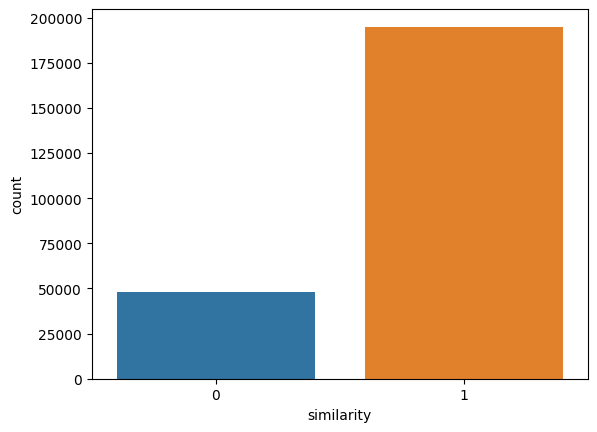

In [43]:
sns.countplot(data=phenotype_comparison_df, x="similarity")

In [44]:
# melt pairwise_pheno_scores_df for columns l1_norm, cosine_similarity, corr
pairwise_pheno_scores_melt = pd.melt(pairwise_pheno_scores_df, id_vars=["genome1", "genome2", "source1", "source2"], var_name="metric", value_name="value")
pairwise_pheno_scores_melt["comp"] = ["-".join(sorted([s1,s2])) for s1, s2 in zip(pairwise_pheno_scores_melt["source1"], pairwise_pheno_scores_melt["source2"])]
pairwise_pheno_scores_melt

,genome1,genome2,source1,source2,metric,value,comp
0,GCF_001421845.1,GCF_001425385.1,Leaf,Leaf,l1_norm,0.012552,Leaf-Leaf
1,GCF_001421315.1,GCF_001423725.1,Leaf,Leaf,l1_norm,0.008368,Leaf-Leaf
2,GCF_001421605.1,GCF_001421155.1,Leaf,Leaf,l1_norm,0.000000,Leaf-Leaf
3,GCF_001421765.1,GCF_001421405.1,Leaf,Leaf,l1_norm,0.008368,Leaf-Leaf
4,GCF_001421355.1,GCF_001421285.1,Leaf,Leaf,l1_norm,0.004184,Leaf-Leaf
...,...,...,...,...,...,...,...
11947,GCF_001421625.1,GCF_920939475.1,Leaf,Leaf,corr,0.705037,Leaf-Leaf
11948,Rhizobium_sp._CF048_2585427590.fna,Rhizobium_lusitanum_YR374_2585427527.fna,PMI,PMI,corr,0.590138,PMI-PMI
11949,g202950.11,g575584.19,CH,CH,corr,0.687769,CH-CH
11950,g1663.229,g1663.235,CH,CH,corr,0.645013,CH-CH


<Axes: xlabel='metric', ylabel='value'>

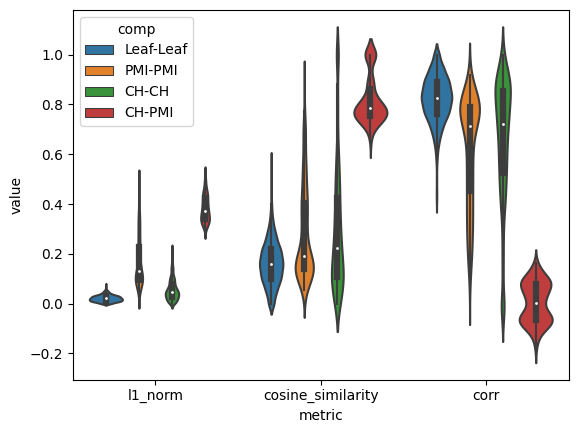

In [55]:
sns.violinplot(data=pairwise_pheno_scores_melt, x="metric", y="value", hue="comp")

In [46]:
def get_genome_similarity(row):
    genome1 = row.genome1
    genome2 = row.genome2
    genome_pair_id = f"{genome1}-{genome2}"
    return top_10000_pairs.loc[genome_pair_id, "ji"]

In [47]:
phenotype_comparison_df["ji"] = phenotype_comparison_df.apply(get_genome_similarity, axis=1)
phenotype_comparison_df["sources"] = ["-".join(sorted([s1, s2])) for s1, s2 in zip(phenotype_comparison_df["source1"], phenotype_comparison_df["source2"])]

/home/g8k/.virtualenvs/trait-prediction-rqyl/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


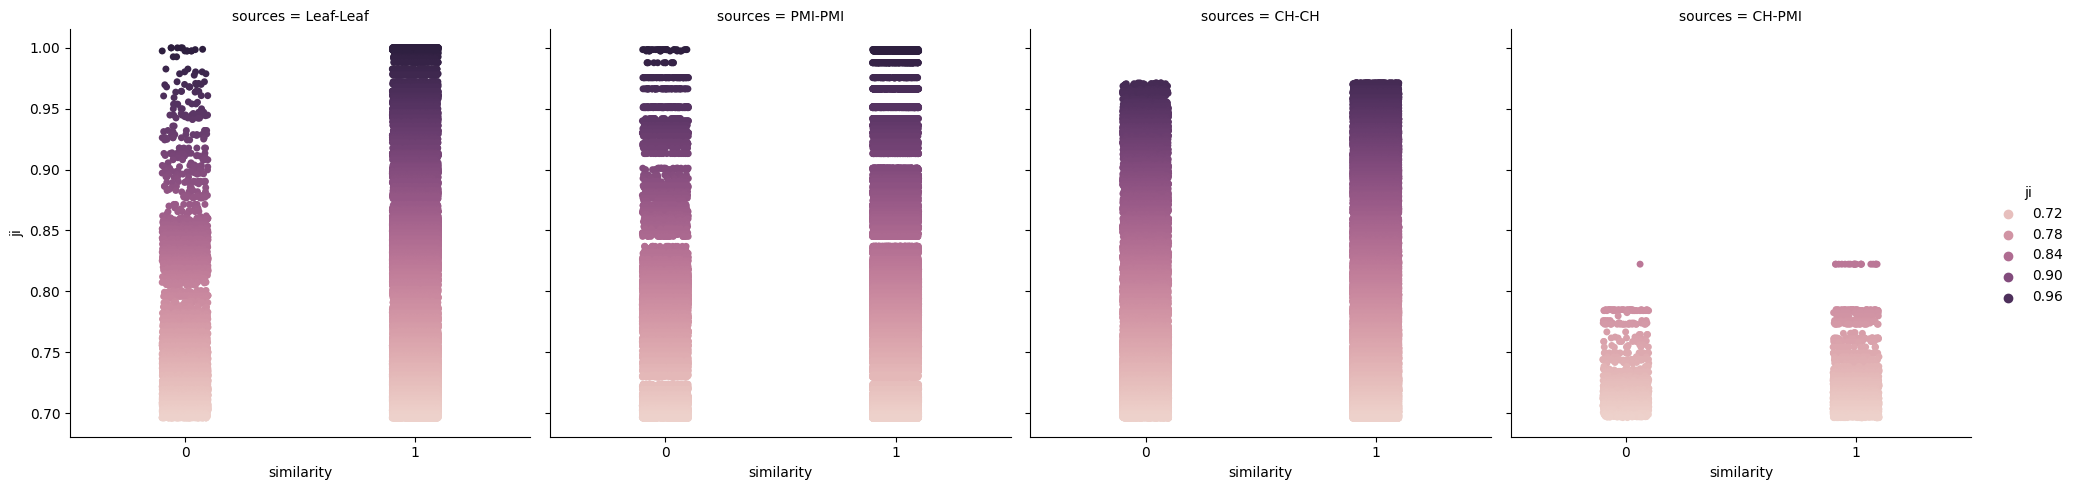

In [50]:
sns.catplot(data=phenotype_comparison_df, x="similarity", y="ji", jitter=True, hue="ji", col="sources")